# Board Games：使用集成學習預測桌遊評分

1. 合併兩個桌遊資料集。
2. 建立一個簡單的迴歸任務：用桌遊基本資訊預測 `bayes_average`。
3. 使用 `RandomForestRegressor` 作為代表性的集成學習模型。
4. 使用 **RMSE** 作為代表性的迴歸評估指標。
5. 透過視覺化觀察評分分布、預測結果與特徵重要性。


## `details.csv` Schema

| 欄位名稱 | 型態 | 最小值 | 最大值 | 平均值 | 標準差 | 說明 |
|---|---:|---:|---:|---:|---:|---|
| `num` | `int64` | 0 | 21,630 | 10,815.00 | 6,244.48 | 資料列流水號，從 0 開始 |
| `id` | `int64` | 1 | 350,992 | 118,133.09 | 105,310.42 | BoardGameGeek 遊戲 ID，可作為資料表合併用的 key |
| `primary` | `object` | — | — | — | — | 遊戲主要名稱，例如 `Pandemic`、`Carcassonne`、`Catan` |
| `description` | `object` | — | — | — | — | 遊戲描述文字，通常是完整的遊戲介紹，可用於文字分析或 NLP 特徵工程 |
| `yearpublished` | `int64` | -3,500 | 2,023 | 1,986.09 | 210.04 | 出版年份；負數可能代表西元前，`0` 可能代表未知年份 |
| `minplayers` | `int64` | 0 | 10 | 2.01 | 0.69 | 最少玩家數 |
| `maxplayers` | `int64` | 0 | 999 | 5.71 | 15.10 | 最多玩家數；極大值如 `999` 可能代表特殊或未限制情況 |
| `playingtime` | `int64` | 0 | 60,000 | 90.51 | 534.83 | 遊玩時間，單位通常為分鐘 |
| `minplaytime` | `int64` | 0 | 60,000 | 63.65 | 447.21 | 最短遊玩時間，單位通常為分鐘 |
| `maxplaytime` | `int64` | 0 | 60,000 | 90.51 | 534.83 | 最長遊玩時間，單位通常為分鐘 |
| `minage` | `int64` | 0 | 25 | 9.61 | 3.64 | 建議最低年齡 |
| `boardgamecategory` | `object` | — | — | — | — | 桌遊類別，為 list-like 字串，例如 `['Medical']`、`['Economic', 'Negotiation']` |
| `boardgamemechanic` | `object` | — | — | — | — | 桌遊機制，為 list-like 字串，例如合作遊戲、手牌管理、擲骰、版圖拼放等 |
| `boardgamefamily` | `object` | — | — | — | — | 桌遊系列、主題家族、元件分類或相關主題，為 list-like 字串 |
| `boardgameexpansion` | `object` | — | — | — | — | 該遊戲的擴充遊戲列表，為 list-like 字串；若沒有擴充，通常可能以空 list 表示 |
| `boardgameimplementation` | `object` | — | — | — | — | 該遊戲的相關實作、重製版、衍生版本或同系統作品，為 list-like 字串 |
| `boardgamedesigner` | `object` | — | — | — | — | 遊戲設計師，為 list-like 字串，例如 `['Matt Leacock']` |
| `boardgameartist` | `object` | — | — | — | — | 遊戲美術設計者，為 list-like 字串 |
| `boardgamepublisher` | `object` | — | — | — | — | 遊戲出版商，為 list-like 字串，例如 `['Z-Man Games', 'Albi', ...]` |
| `owned` | `int64` | 0 | 168,364 | 1,487.92 | 5,395.08 | 擁有此遊戲的人數，可視為遊戲普及程度指標 |
| `trading` | `int64` | 0 | 2,508 | 43.59 | 102.41 | 願意交易此遊戲的人數 |
| `wanting` | `int64` | 0 | 2,011 | 42.03 | 117.94 | 想要獲得此遊戲的人數 |
| `wishing` | `int64` | 0 | 19,325 | 233.66 | 800.66 | 將此遊戲加入願望清單的人數 |

## `ratings.csv` Schema

| 欄位名稱 | 型態 | 最小值 | 最大值 | 平均值 | 標準差 | 說明 |
|---|---:|---:|---:|---:|---:|---|
| `num` | `int64` | 0 | 21,830 | 10,915.00 | 6,302.21 | 排名索引，從 0 開始；大致等於 `rank - 1` |
| `id` | `int64` | 1 | 350,992 | 118,144.78 | 105,369.55 | BoardGameGeek 遊戲 ID，可與 `details.csv` 的 `id` 合併 |
| `name` | `object` | — | — | — | — | 遊戲名稱，例如 `Pandemic`、`Carcassonne`、`Catan` |
| `year` | `int64` | 0 | 3,500 | 1,987.44 | 193.51 | 出版年份；`0` 可能代表未知年份 |
| `rank` | `int64` | 1 | 21,831 | 10,916.00 | 6,302.21 | BoardGameGeek 排名，數值越小代表排名越前面 |
| `average` | `float64` | 1.04 | 9.57 | 6.42 | 0.93 | 使用者平均評分 |
| `bayes_average` | `float64` | 0 | 8.51 | 5.68 | 0.36 | Bayesian 平均評分，通常比一般平均分數更適合用於排序 |
| `users_rated` | `int64` | 30 | 108,975 | 866.96 | 3,679.82 | 參與評分的使用者人數 |
| `url` | `object` | — | — | — | — | BoardGameGeek 遊戲頁面的相對路徑，例如 `/boardgame/30549/pandemic` |
| `thumbnail` | `object` | — | — | — | — | 遊戲縮圖圖片 URL |

In [1]:
# ============================================================
# 1. 讀取資料與初步檢視
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

details = pd.read_csv("./details.csv")
ratings = pd.read_csv("./ratings.csv")

print("details.csv 的資料筆數與欄位數：")
print(details.shape)

print("ratings.csv 的資料筆數與欄位數：")
print(ratings.shape)

print("details.csv 前 5 筆資料：")
display(details.head())

print("ratings.csv 前 5 筆資料：")
display(ratings.head())

details.csv 的資料筆數與欄位數：
(21631, 23)
ratings.csv 的資料筆數與欄位數：
(21831, 10)
details.csv 前 5 筆資料：


,num,id,primary,description,yearpublished,minplayers,maxplayers,playingtime,minplaytime,maxplaytime,...,boardgamefamily,boardgameexpansion,boardgameimplementation,boardgamedesigner,boardgameartist,boardgamepublisher,owned,trading,wanting,wishing
0,0,30549,Pandemic,"In Pandemic, several virulent diseases have br...",2008,2,4,45,45,45,...,"['Components: Map (Global Scale)', 'Components...",['Pandemic: Gen Con 2016 Promos – Z-Force Team...,"['Pandemic Legacy: Season 0', 'Pandemic Legacy...",['Matt Leacock'],"['Josh Cappel', 'Christian Hanisch', 'Régis Mo...","['Z-Man Games', 'Albi', 'Asmodee', 'Asmodee It...",168364,2508,625,9344
1,1,822,Carcassonne,Carcassonne is a tile-placement game in which ...,2000,2,5,45,30,45,...,"['Cities: Carcassonne (France)', 'Components: ...","['20 Jahre Darmstadt Spielt', 'Apothecaries (f...","['The Ark of the Covenant', 'Carcassonne für 2...",['Klaus-Jürgen Wrede'],"['Doris Matthäus', 'Anne Pätzke', 'Chris Quill...","['Hans im Glück', '999 Games', 'Albi', 'Bard C...",161299,1716,582,7383
2,2,13,Catan,"In CATAN (formerly The Settlers of Catan), pla...",1995,3,4,120,60,120,...,"['Animals: Sheep', 'Components: Hexagonal Tile...","['20 Jahre Darmstadt Spielt', 'Brettspiel Adve...","['Baden-Württemberg Catan', 'Catan Geographies...",['Klaus Teuber'],"['Volkan Baga', 'Tanja Donner', 'Pete Fenlon',...","['KOSMOS', '999 Games', 'Albi', 'Asmodee', 'As...",167733,2018,485,5890
3,3,68448,7 Wonders,You are the leader of one of the 7 great citie...,2010,2,7,30,30,30,...,"['Ancient: Babylon', 'Ancient: Egypt', 'Ancien...","['7 Wonders: Armada', '7 Wonders: Babel', '7 W...","['7 Wonders (Second Edition)', '7 Wonders Duel...",['Antoine Bauza'],"['Dimitri Chappuis', 'Miguel Coimbra', 'Etienn...","['Repos Production', 'ADC Blackfire Entertainm...",120466,1567,1010,12105
4,4,36218,Dominion,"&quot;You are a monarch, like your parents bef...",2008,2,4,30,30,30,...,"['Crowdfunding: Wspieram', 'Game: Dominion', '...","['Ancient Times (fan expansion for Dominion)',...","['Dominion (Second Edition)', 'Het Koninkrijk ...",['Donald X. Vaccarino'],"['Matthias Catrein', 'Julien Delval', 'Tomasz ...","['Rio Grande Games', '999 Games', 'Albi', 'Bar...",106956,2009,655,8621


ratings.csv 前 5 筆資料：


,num,id,name,year,rank,average,bayes_average,users_rated,url,thumbnail
0,105,30549,Pandemic,2008,106,7.59,7.487,108975,/boardgame/30549/pandemic,https://cf.geekdo-images.com/S3ybV1LAp-8SnHIXL...
1,189,822,Carcassonne,2000,190,7.42,7.309,108738,/boardgame/822/carcassonne,https://cf.geekdo-images.com/okM0dq_bEXnbyQTOv...
2,428,13,Catan,1995,429,7.14,6.970,108024,/boardgame/13/catan,https://cf.geekdo-images.com/W3Bsga_uLP9kO91gZ...
3,72,68448,7 Wonders,2010,73,7.74,7.634,89982,/boardgame/68448/7-wonders,https://cf.geekdo-images.com/RvFVTEpnbb4NM7k0I...
4,103,36218,Dominion,2008,104,7.61,7.499,81561,/boardgame/36218/dominion,https://cf.geekdo-images.com/j6iQpZ4XkemZP07HN...


In [2]:
# ============================================================
# 2. 合併 details 與 ratings
# ============================================================

# 兩個資料集都有 id 欄位，因此可以用 id 將桌遊基本資料與評分資料合併。
# 為了避免欄位太多，ratings 只保留本範例需要的欄位。
ratings_part = ratings[[
    "id",
    "average",
    "bayes_average",
    "users_rated",
    "rank"
]]

board_games = pd.merge(
    details,
    ratings_part,
    on="id",
    how="inner"
)

print("合併後的資料筆數與欄位數：")
print(board_games.shape)

print("合併後前 5 筆資料：")
display(board_games.head())

print("本範例目標欄位 bayes_average 的基本統計：")
display(board_games["bayes_average"].describe().to_frame())

合併後的資料筆數與欄位數：
(21631, 27)
合併後前 5 筆資料：


,num,id,primary,description,yearpublished,minplayers,maxplayers,playingtime,minplaytime,maxplaytime,...,boardgameartist,boardgamepublisher,owned,trading,wanting,wishing,average,bayes_average,users_rated,rank
0,0,30549,Pandemic,"In Pandemic, several virulent diseases have br...",2008,2,4,45,45,45,...,"['Josh Cappel', 'Christian Hanisch', 'Régis Mo...","['Z-Man Games', 'Albi', 'Asmodee', 'Asmodee It...",168364,2508,625,9344,7.59,7.487,108975,106
1,1,822,Carcassonne,Carcassonne is a tile-placement game in which ...,2000,2,5,45,30,45,...,"['Doris Matthäus', 'Anne Pätzke', 'Chris Quill...","['Hans im Glück', '999 Games', 'Albi', 'Bard C...",161299,1716,582,7383,7.42,7.309,108738,190
2,2,13,Catan,"In CATAN (formerly The Settlers of Catan), pla...",1995,3,4,120,60,120,...,"['Volkan Baga', 'Tanja Donner', 'Pete Fenlon',...","['KOSMOS', '999 Games', 'Albi', 'Asmodee', 'As...",167733,2018,485,5890,7.14,6.970,108024,429
3,3,68448,7 Wonders,You are the leader of one of the 7 great citie...,2010,2,7,30,30,30,...,"['Dimitri Chappuis', 'Miguel Coimbra', 'Etienn...","['Repos Production', 'ADC Blackfire Entertainm...",120466,1567,1010,12105,7.74,7.634,89982,73
4,4,36218,Dominion,"&quot;You are a monarch, like your parents bef...",2008,2,4,30,30,30,...,"['Matthias Catrein', 'Julien Delval', 'Tomasz ...","['Rio Grande Games', '999 Games', 'Albi', 'Bar...",106956,2009,655,8621,7.61,7.499,81561,104


本範例目標欄位 bayes_average 的基本統計：


,bayes_average
count,21631.000000
mean,5.683664
std,0.366096
min,0.000000
25%,5.510000
50%,5.546000
75%,5.678000
max,8.511000


每個欄位的遺漏值數量：


,missing_count
boardgameimplementation,16769
boardgameexpansion,16125
boardgameartist,5907
boardgamefamily,3761
boardgamemechanic,1590
boardgamedesigner,596
boardgamecategory,283
boardgamepublisher,1
description,1
id,0


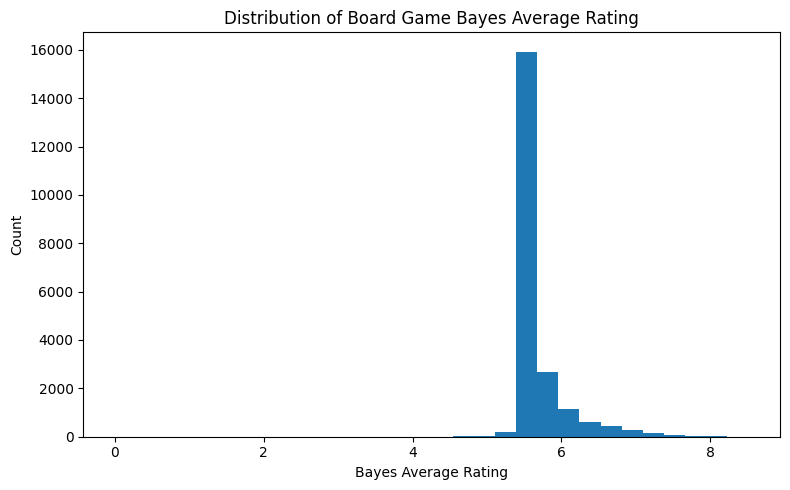

In [3]:
# ============================================================
# 3. 遺漏值檢查與目標變數視覺化
# ============================================================

print("每個欄位的遺漏值數量：")
missing_table = board_games.isna().sum().sort_values(ascending=False).to_frame("missing_count")
display(missing_table.head(15))

# bayes_average 是本範例要預測的目標。
# 先觀察評分分布，了解大多數桌遊的分數集中在哪裡。
plt.figure(figsize=(8, 5))
plt.hist(board_games["bayes_average"], bins=30)
plt.title("Distribution of Board Game Bayes Average Rating")
plt.xlabel("Bayes Average Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# 4. 準備建模資料
# ============================================================

# 本範例只使用數值型欄位，讓課堂範例保持簡單。
# 注意：
# - average 是一般平均分數，和目標 bayes_average 很接近，所以不拿來當特徵。
# - rank 是由評分排序而來，也不拿來當特徵，避免模型偷看到答案。
# - id、num 只是編號，不適合作為預測特徵。
features = [
    "yearpublished",
    "minplayers",
    "maxplayers",
    "playingtime",
    "minplaytime",
    "maxplaytime",
    "minage",
    "owned",
    "trading",
    "wanting",
    "wishing",
    "users_rated"
]

target = "bayes_average"

model_data = board_games[features + [target]]

# 移除少數不適合教學示範的資料：
# 1. bayes_average 等於 0 的資料
# 2. yearpublished 小於等於 0 的資料
model_data = model_data[model_data[target] > 0]
model_data = model_data[model_data["yearpublished"] > 0]

print("建模使用的資料筆數與欄位數：")
print(model_data.shape)

print("建模使用的特徵欄位：")
for feature in features:
    print("-", feature)

print("建模資料前 5 筆：")
display(model_data.head())

建模使用的資料筆數與欄位數：
(21435, 13)
建模使用的特徵欄位：
- yearpublished
- minplayers
- maxplayers
- playingtime
- minplaytime
- maxplaytime
- minage
- owned
- trading
- wanting
- wishing
- users_rated
建模資料前 5 筆：


,yearpublished,minplayers,maxplayers,playingtime,minplaytime,maxplaytime,minage,owned,trading,wanting,wishing,users_rated,bayes_average
0,2008,2,4,45,45,45,8,168364,2508,625,9344,108975,7.487
1,2000,2,5,45,30,45,7,161299,1716,582,7383,108738,7.309
2,1995,3,4,120,60,120,10,167733,2018,485,5890,108024,6.970
3,2010,2,7,30,30,30,10,120466,1567,1010,12105,89982,7.634
4,2008,2,4,30,30,30,13,106956,2009,655,8621,81561,7.499


In [5]:
# ============================================================
# 5. 切分訓練資料與測試資料，並訓練 Random Forest
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = model_data[features].copy()
y = model_data[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)

# Random Forest 是多棵決策樹的集成模型。
# 每棵樹會看到不同的抽樣資料與不同的特徵切分結果，
# 最後再把多棵樹的預測結果取平均。
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=0,
    n_jobs=1
)
rf_model.fit(X_train, y_train)

print("訓練資料筆數：", X_train.shape[0])
print("測試資料筆數：", X_test.shape[0])

訓練資料筆數： 17148
測試資料筆數： 4287


RandomForestRegressor 測試資料 RMSE：
0.0944


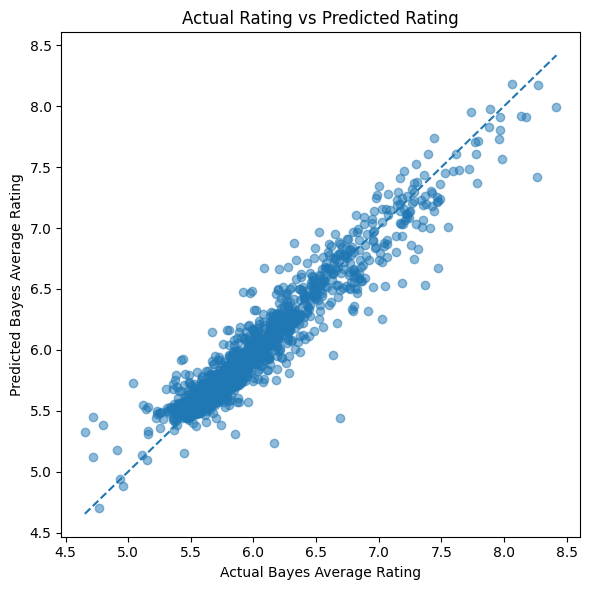

前 10 筆測試資料的真實值與預測值：


,actual_rating,predicted_rating
0,6.369,6.498613
1,5.499,5.498386
2,8.136,7.922994
3,5.552,5.523560
4,5.521,5.508220
5,5.510,5.507135
6,5.725,5.719801
7,5.515,5.524837
8,5.519,5.573859
9,5.529,5.685479


In [6]:
# ============================================================
# 6. 使用 RMSE 評估模型，並視覺化預測結果
# ============================================================

from sklearn.metrics import mean_squared_error

y_pred = rf_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("RandomForestRegressor 測試資料 RMSE：")
print(round(rmse, 4))

# 真實值與預測值越接近，點就越接近對角線。
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)

min_rating = min(y_test.min(), y_pred.min())
max_rating = max(y_test.max(), y_pred.max())

plt.plot(
    [min_rating, max_rating],
    [min_rating, max_rating],
    linestyle="--"
)

plt.title("Actual Rating vs Predicted Rating")
plt.xlabel("Actual Bayes Average Rating")
plt.ylabel("Predicted Bayes Average Rating")
plt.tight_layout()
plt.show()

result_table = pd.DataFrame()
result_table["actual_rating"] = y_test.values
result_table["predicted_rating"] = y_pred

print("前 10 筆測試資料的真實值與預測值：")
display(result_table.head(10))

In [ ]:
# ============================================================
# 7. Random Forest 特徵重要性
# ============================================================

# Random Forest 可以估計每個特徵對預測結果的重要程度。
# 數值越大，代表模型越常使用該特徵來有效切分資料。
importance_table = pd.DataFrame()
importance_table["feature"] = features
importance_table["importance"] = rf_model.feature_importances_

importance_table = importance_table.sort_values(
    by="importance",
    ascending=False
)

print("Random Forest 特徵重要性：")
display(importance_table)

plt.figure(figsize=(9, 5))
plt.bar(importance_table["feature"], importance_table["importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()